# Time Series Forecasting - Exploratory Data Analysis

## Objective

The objective of this project is to forecast weekly sales for Walmart stores based on historical sales, store characteristics, and external economic indicators. I chose this dataset specifically because it includes built-in `IsHoliday` and store `Type`/`Size` features, allowing holiday and store-segment analysis without constructing a custom holiday calendar or segmentation logic. My initial candidate research directions for analysis are: 

1. Holiday effects — whether sales around holidays reflect genuine demand increase, or a shift in when purchases happen rather than a net gain.
    
2. Store-Type effects — whether store `Type` (A/B/C) and `Size` predict differences in sales level or volatility. 
    
3. Economic factors — whether external indicators (`CPI`, `Unemployment`, `Fuel_Price`) show a relationship with sales, and whether they interact with the holiday effect. 

Instead of committing to a single question first, I'm following a pattern-first approach: I'll use the EDA in this notebook to identify which of these candidate directions shows the clearest, most explainable signal, and then narrow down to a specific research question once the data justifies it. 

[placeholder — note which direction(s) held up, or dropped, and the finalized research question]

In this notebook, the objective is to understand the structure, distributions, and relationships in the merged Walmart sales dataset to inform which of these directions to pursue, how to prepare the data, and inform feature engineering decisions.

## Inputs
- `train.csv` — historical weekly sales by `Store`, `Dept`, `Date`, with `IsHoliday` flag
- `stores.csv` — store-level metadata: `Store`, `Type` (A/B/C), `Size`
- `features.csv` — store-week-level external factors: `Temperature`, `Fuel_Price`, `CPI`, `Unemployment`, `MarkDown1-5`, `IsHoliday`

Merged on `Store` (`train.csv` + `stores.csv`) and `['Store', 'Date']` (+ features), forming one dataframe of 421,570 rows spanning `2010-02-05` - `2012-10-26`.

## Outputs 
- Finalized research question
- cleaning/feature engineering decisions 

## 1.1 Setup & Import

importing libraries and setting paths for reproducability

In [2]:
import warnings
warnings.filterwarnings('ignore') # suppress outputs of warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (10, 6)

FEATURES_PATH = '../data/raw/features.csv'
STORES_PATH = '../data/raw/stores.csv'
TRAIN_PATH = '../data/raw/train.csv'
RANDOM_STATE = 42

Setting up the datafram combining the three datasets into one. This is done using pandas merge, merging train.csv with stores.csv on `Store`, and the dataframe from that merge with features.csv on `['Store', 'Date']`. Merging on `['Store', 'Date']` prevents the risk of duplicating rows from a partial or single-column join on a table that isn't one-row-per-key. 

In [3]:
train = pd.read_csv(TRAIN_PATH)
stores = pd.read_csv(STORES_PATH)
features = pd.read_csv(FEATURES_PATH)

In [4]:
df = train.merge(stores, on='Store', how='left')
df = df.merge(features, on=['Store', 'Date'], how='left')

In [4]:
# quick sanity check, df and train should have the same row count since i merged 'left'
print(df.shape) 
train.shape

(421570, 17)


(421570, 5)

The new dataframe and the train dataset having the same number of rows confirms the merge did not drop or duplicate rows.

## 1.2 Data Cleaning and Sanity Check

Because both `features.csv` and `train.csv` have a `IsHoliday` column, after merging, the new dataframe has `IsHoliday_x` and `IsHoliday_y`. If both of these columns are equivalent then I will drop one and rename the other to `IsHoliday` since it would be repetitive and uncecessary to keep both. 

In [5]:
(df['IsHoliday_x'] == df['IsHoliday_y']).value_counts()

True    421570
Name: count, dtype: int64

all rows of `IsHoliday_x` and `IsHoliday_y` are equivalent so I will drop `IsHoliday_y` and rename `IsHoliday_x` to `IsHoliday`. 

In [6]:
df = df.drop(columns=['IsHoliday_y'])
df = df.rename(columns={'IsHoliday_x': 'IsHoliday'})

### Datetime Conversion
To enable time-based plotting/resampling or sorting, I convert the dates to pandas datetime format. 

In [7]:
df['Date'] = pd.to_datetime(df['Date'])

### Missing Value Check
Looking at the raw data files and data description, I already know `features.csv` has mostly `NaN` for `MarkDown1-5`(they are only populated starting Nov 2011), so I will use `.isnull().sum()` to check the number of `NaN`s present in the dataframe. I will decide whether to drop them now, fill with 0s, or handle later if they are not central to patterns worth researching. 

In [8]:
df.isnull().sum()

Store                0
Dept                 0
Date                 0
Weekly_Sales         0
IsHoliday            0
Type                 0
Size                 0
Temperature          0
Fuel_Price           0
MarkDown1       270889
MarkDown2       310322
MarkDown3       284479
MarkDown4       286603
MarkDown5       270138
CPI                  0
Unemployment         0
dtype: int64

The only `NaN` values exist in the `MarkDown1-5` columns, which is expected. Since they do not affect any of the other variables of interest I will ignore them for now and handle in feature engineering (what even are the `MarkDowns1-5` supposed to be like marking down on items liek reducing their prices?). This confirms no `NaN` missingness outside `MarkDowns1-5`, though non-obvious missing/impossible values still need checking.

### Sanity Checks
I will check to make sure the data types of the features are as they should be, and use `.describe()` to check for any potential outliers or impossible values. 

In [9]:
df.dtypes

Store                    int64
Dept                     int64
Date            datetime64[us]
Weekly_Sales           float64
IsHoliday                 bool
Type                       str
Size                     int64
Temperature            float64
Fuel_Price             float64
MarkDown1              float64
MarkDown2              float64
MarkDown3              float64
MarkDown4              float64
MarkDown5              float64
CPI                    float64
Unemployment           float64
dtype: object

All `dtypes` of the features are correct.

In [10]:
df.describe()

,Store,Dept,Date,Weekly_Sales,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
count,421570.000000,421570.000000,421570,421570.000000,421570.000000,421570.000000,421570.000000,150681.000000,111248.000000,137091.000000,134967.000000,151432.000000,421570.000000,421570.000000
mean,22.200546,44.260317,2011-06-18 08:30:31.963375,15981.258123,136727.915739,60.090059,3.361027,7246.420196,3334.628621,1439.421384,3383.168256,4628.975079,171.201947,7.960289
min,1.000000,1.000000,2010-02-05 00:00:00,-4988.940000,34875.000000,-2.060000,2.472000,0.270000,-265.760000,-29.100000,0.220000,135.160000,126.064000,3.879000
25%,11.000000,18.000000,2010-10-08 00:00:00,2079.650000,93638.000000,46.680000,2.933000,2240.270000,41.600000,5.080000,504.220000,1878.440000,132.022667,6.891000
50%,22.000000,37.000000,2011-06-17 00:00:00,7612.030000,140167.000000,62.090000,3.452000,5347.450000,192.000000,24.600000,1481.310000,3359.450000,182.318780,7.866000
75%,33.000000,74.000000,2012-02-24 00:00:00,20205.852500,202505.000000,74.280000,3.738000,9210.900000,1926.940000,103.990000,3595.040000,5563.800000,212.416993,8.572000
max,45.000000,99.000000,2012-10-26 00:00:00,693099.360000,219622.000000,100.140000,4.468000,88646.760000,104519.540000,141630.610000,67474.850000,108519.280000,227.232807,14.313000
std,12.785297,30.492054,NaN,22711.183519,60980.583328,18.447931,0.458515,8291.221345,9475.357325,9623.078290,6292.384031,5962.887455,39.159276,1.863296


- `Store`: Nothing stands out, slightly large difference between `max` (45) and `75%` (33), but no impossible values present. 

- `Dept`: This feature holds categorical/ID code values, so interpretation is different, but there appears to be no impossible value since the lowest `Dept` is 1.0. 

- `Date`: Similar to `Dept`, interpretation is different for this features, so nothing important to identify here. It may be helpful to know that the time frame ranges from `2010-02-05`-`2012-10-26`. 

- `Weekly_Sales`: Very big outlier, `max` is 693099.36 compared to `75%` 20205.85. Additionally, `50%` is only 7612.03, but `mean` is 15981.26. I expect to see a left skewed distribution for this feature. Also, The negative `min`(-4988.94), while not impossible, will either need to be dropped or kept as legitimate. I will defer the decision to keep or drop the negative sales to feature engineering. 

- `Size`: Nothing really stands out. The `max` (219622.00) and `75%` (202505.00) aren't too different, the `mean` (136727.92) and `50%` (140167.00) are relatively close.  The large `std` (60980.58) is not concerning given this feature captures stores sizes and sizes will nautrally vary.

- `Temperature`: Potential outlier of `max` 100.14 and `75%` 74.28, but `mean` and `50%` only differs by 2.0. A `min` of -2.00 isn't impossible. 

- `Fuel_Price`: Nothing to note, no impossible values or outliers. Very small `std` of 0.46. 

- `MarkDown1`: The `mean` (7246.42) and `50%` (5347.45)have a difference of ~2000, `min` of 0.27 is possible, the `75%` (9210.90) and `max` (88646.76) are very different, so an outlier exists. I expect to see a skewed distribution. 

- `MarkDown2`: Very negative `min` (-265.76), which is very suspicious since a negative mark down does not make real world sense. The `mean` (3334.62) and `50%` (192.0) are very different so there is likely an outlier, and the `75%` (1926.94) and `max` (104519.54) confirm this by the large difference.

- `MarkDown3`: `min` is -29, which again is suspicious since a negative mark down doesn't make sense. `mean` (1439.42) is very different from `50%` (24.60), and `75%`(103.99) and `max` (141630.61) are also very different. I expect to see a skewed distribution.

- `MarkDown4`: There is a large difference between `mean` (3383.16) and `50%` (1481.31), and an even larger difference between `max` (67474.85) and `75%`(3595.04). I expect to see a skewed distribution. The `min` is a possible 0.22. 

- `MarkDown5`:  `max` (108519.28) and `75%` (5563.80) have a very large difference, so `max` is an outlier. This is supported by the difference between `mean` (4628.97) and `50%` (3359.45). I expect to see a skewed distribution. 

All the `MarkDown` columns have differing counts, and are expected to show skewed distributions, which will need to be accounted for when comparing them.

- `CPI`: The `mean` (171.20) is slightly below `50%` (182.3), and `max` (227.23) and `75%` (212.41) differ slightly, so I expect to see a slightly left skewed distribution. `min` is 128.06, which is a realistic value.

- `unemployment`: `mean` (7.96) and `50%` (7.87) are relatively close, but there is a definite outlier in `max` (14.313000) since `75%` is 8.57. The `min` (3.87) is a realistic value. I expect to see a relatively balanced distribution with a long tail to the outlier. 

To check the distribution of `Type`, I use `value_counts()`, which is row-level and could be skewed by stores having different numbers of departments. To confirm the distribution reflects actual store counts rather than department density, I re-run it with `.drop_duplicates(subset='Store')` first.

In [10]:
print(df.drop_duplicates(subset='Store')['Type'].value_counts())
df['Type'].value_counts()

Type
A    22
B    17
C     6
Name: count, dtype: int64


Type
A    215478
B    163495
C     42597
Name: count, dtype: int64

Both outputs show `Type` A is most common, with `Type` C being notably rare — only 6 actual stores. This confirms the row-level imbalance is driven by store count, not department count. I'll need to account for this sample size limitation during analysis, since any apparent `Type` C effect could be noise from a small sample rather than a genuine pattern.

## 1.3 Univariate Analysis

To visualize and analyze the features, looking at distributions and potential outliers, I conduct univariate analysis using a histogram with a KDE curve overlay for the continuous variables (`Weekly_Sales`, `Size`, `Temperature`, `Fuel_Price`, `MarkDown1-5`, `CPI`, `Unemployment`), and a countplot for the categorical/ID variables (`Type`, `IsHoliday`, `Store`, `Dept`). The KDE curve overlay plots a smoothed curve that makes it visually easier to see skew direction and multimodality. `Store` and `Dept` are included in categorical analysis becuase they are labels and their numeric values don't carry meaning in their magnitude or spacing. 

`Date` is excluded from this analysis since it will be examined separately later in the time series structure section, since its analytical value is in trend over time rather than distribution shape. 

### Continuous Features: 
`Weekly_Sales`, `Size`, `Temperature`, `Fuel_Price`, `MarkDown1-5`, `CPI`, `Unemployment`

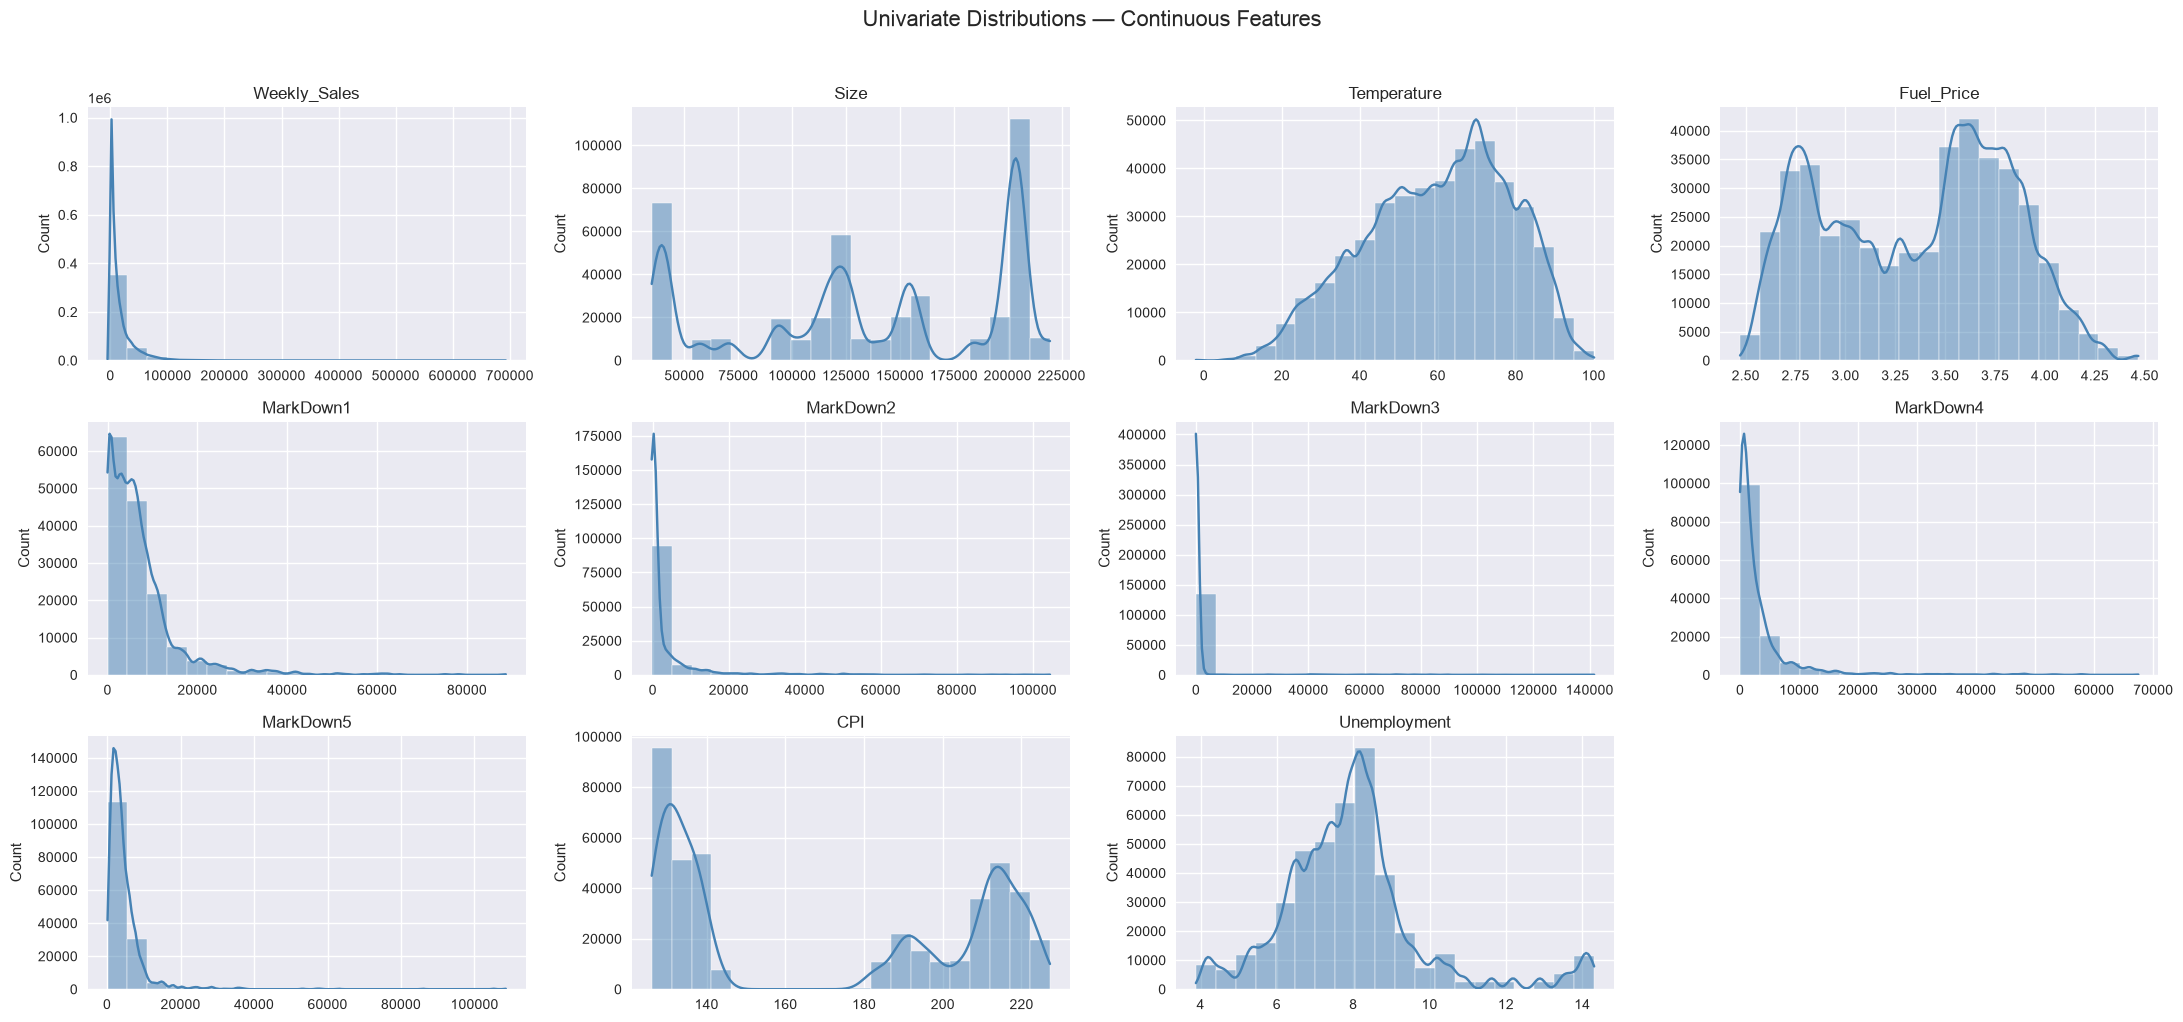

In [11]:
continuous_features = ['Weekly_Sales', 'Size', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment']

fig, axes = plt.subplots(3, 4, figsize=(22, 10))
axes = axes.flatten()

for i, feature in enumerate(continuous_features):
    sns.histplot(df[feature], bins=20, kde=True, ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].set_title(feature)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')

axes[-1].set_visible(False)

fig.suptitle('Univariate Distributions — Continuous Features', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('../images/continuous_distributions.png', bbox_inches='tight')
plt.show()

- `Weekly_Sales`: Heavily left-skewed distribution as expected from sanity check, and is common for weekly sales distributions to have heavy left-skews. The majority of sales are clustered near 0. Since the full-range histogram would never sjow negative numbers I'm relying on `.describe()` to confirm the negitive min exists.

- `Size`: Has varying distribution with multiple peaks, the highest around 200,000. 

- `Temperature`: This graph is slightly left skewed. the highest peak is around 70. 

- `Fuel_Price`: this is bimodal with a peak at ~2.75 and another ~3.60. 

- `MarkDown1-5`: As expected all the `MarkDown`s are heavily right skewed. Since all the `Markdown`s have different counts the graphs themselves can be misleading, but overall they share roughly the same shape and distribution even if the counts and values are different. 

- `CPI`: Has the highest peak at ~120 and is flat at 0 from ~140-~180, and has another peak at ~210. The distribution is not very balanced and almost bimodal? 

- `Unemployment`: the distribution is slightly right skewed with most values between 4-8 and then a drastic drop from 9-14. 

In [13]:
print(df['Store'].nunique())
df['Dept'].nunique()


45


81

### Categorical Features: 
`Type`, `IsHoliday`, `Store`, `Dept`

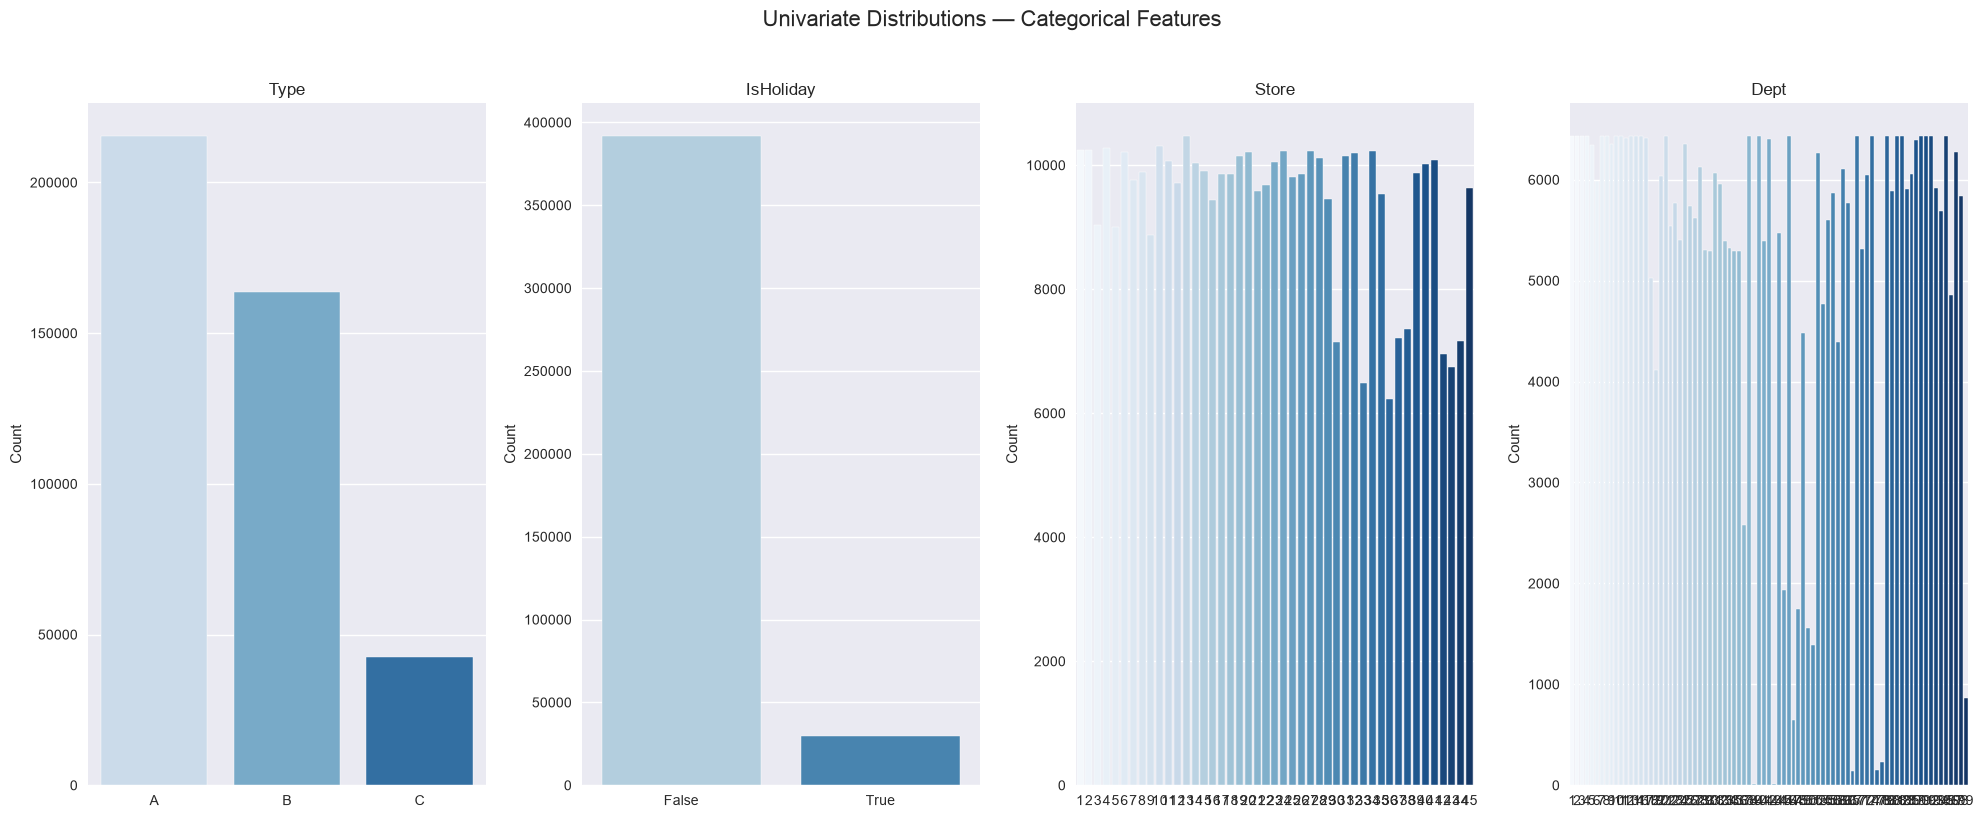

In [ ]:
categorical_features = ['Type', 'IsHoliday', 'Store', 'Dept']

fig, axes = plt.subplots(1, 4, figsize=(20, 8))
axes = axes.flatten()

for i, feature in enumerate(categorical_features):
    sns.countplot(x=feature, data=df, ax=axes[i], palette='Blues')
    axes[i].set_title(feature)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')

fig.suptitle('Univariate Distributions — Categorical Features', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('../images/categorical_distributions.png', bbox_inches='tight')
plt.show()

## 1.4 Time Series Structure

## 1.5 Segment Comparison

## 1.6 Holiday Effect Analysis

## 1.7 Findings / Research Question